In [1]:
import pandas as pd,numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import baostock as bs
import datetime

from scipy import stats
from scipy.stats import t
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller,acf,pacf,grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose,STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.vecm import coint_johansen,VECM
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.stats.multitest import multipletests

from arch import arch_model

from sklearn.linear_model import Ridge,LinearRegression
from sklearn.ensemble import RandomForestRegressor ,IsolationForest
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.decomposition import PCA
# 构建XGBoost模型
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error,mean_absolute_error

import pmdarima as pm

#深度学习
import torch
import torch.nn as nn

plt.rcParams['font.sans-serif'] = ['SimHei']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 获取交易股票数据 - 中证生物医药
lg = bs.login()
rs = bs.query_history_k_data_plus(
    "sz.399441",  # 上海市场需加 sh. 前缀
    "date,open,high,low,close,volume",
    start_date="2020-01-01",
    end_date="2026-7-31"
)
# 处理数据...
bs.logout()

login success!
logout success!


In [3]:
data = pd.DataFrame(rs.data,columns=['date','open','high','low','close','volume'])
# data.to_csv(r'../data/399441.csv',encoding='utf-8-sig',index=False)
data.head(2)

,date,open,high,low,close,volume
0,2020-01-02,3157.1460,3158.4070,3116.8320,3134.4600,375300176
1,2020-01-03,3140.9140,3149.6660,3125.4310,3130.9200,260885828


In [4]:
# 将文本数据转换成数字格式
col=['open','high','low','close','volume']
for c in col:
    data[c] = pd.to_numeric(data[c])

In [5]:
data['date'] = pd.to_datetime(data['date'])
data = data.set_index('date')
data = data.sort_index()
data.describe()

,open,high,low,close,volume
count,1594.000000,1594.000000,1594.000000,1594.000000,1.594000e+03
mean,3457.572335,3503.312658,3412.955169,3457.551524,3.911848e+08
std,1407.443043,1430.828946,1380.564811,1406.928987,1.692752e+08
min,1726.148500,1729.489900,1708.926100,1724.838500,1.380061e+08
25%,2194.729650,2217.747325,2171.536450,2198.281275,2.751473e+08
50%,3080.284100,3144.928450,3049.647000,3080.030200,3.538203e+08
75%,4515.046925,4545.793850,4457.012450,4513.051975,4.555782e+08
max,7038.358900,7181.061500,6804.349900,7028.576000,1.633647e+09


In [6]:
# 整体CV - 离散系数
data.std()/data.mean() * 100

open      40.706106
high      40.842171
low       40.450716
close     40.691483
volume    43.272436
dtype: float64

In [7]:
# 检查缺失值
data.isnull().sum()

open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [8]:
# 各年度的整体情况
data_stats = data.groupby(data.index.year)['close'].agg(['mean','sum','std','min','max'])
data_stats['cv'] = data_stats['std']/data_stats['mean'] * 100
data_stats

,mean,sum,std,min,max,cv
date,,,,,,
2020,4830.996833,1.173932e+06,992.379487,3108.5200,7028.5760,20.541920
2021,5630.955404,1.368322e+06,514.176590,4774.2938,6626.0484,9.131250
2022,3755.478476,9.088258e+05,393.575015,2970.0427,4735.0324,10.480023
2023,2994.685986,7.247140e+05,347.380529,2574.0176,3870.7686,11.599898
2024,2126.967421,5.147261e+05,206.515423,1724.8385,2658.0900,9.709383
2025,2177.686488,5.291778e+05,189.906244,1905.2029,2589.1115,8.720550
2026,2098.122330,2.916390e+05,137.162205,1778.5048,2362.3070,6.537379


In [9]:
#月度的整体情况
data_stats_month = data.groupby(data.index.month)['close'].agg(['mean','sum','std','min','max'])
data_stats_month['cv'] = data_stats_month['std']/data_stats_month['mean'] * 100

In [10]:
# 单日数据的整体情况
data_stats_day = data.groupby(data.index.day)['close'].agg(['mean','sum','std','min','max'])
data_stats_day['cv'] = data_stats_day['std']/data_stats_day['mean'] * 100

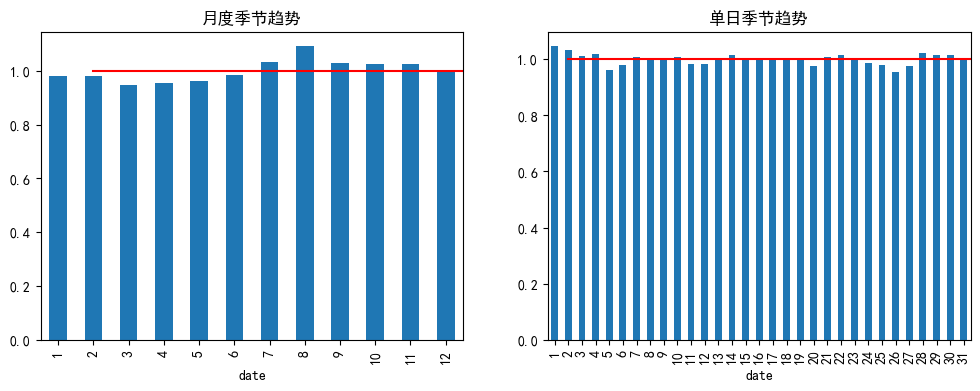

In [11]:
fig,axs = plt.subplots(1,2,figsize=(12,4))
(data_stats_month['mean']/data['close'].mean()).plot.bar(ax=axs[0])
x = np.array([1]*len(data_stats_month))
axs[0].plot(data_stats_month.index,x,color='red')
axs[0].set_title('月度季节趋势')
(data_stats_day['mean']/data['close'].mean()).plot.bar(ax=axs[1])
y = np.array([1]*len(data_stats_day))
axs[1].plot(data_stats_day.index,y,color='red')
axs[1].set_title('单日季节趋势')
plt.show()

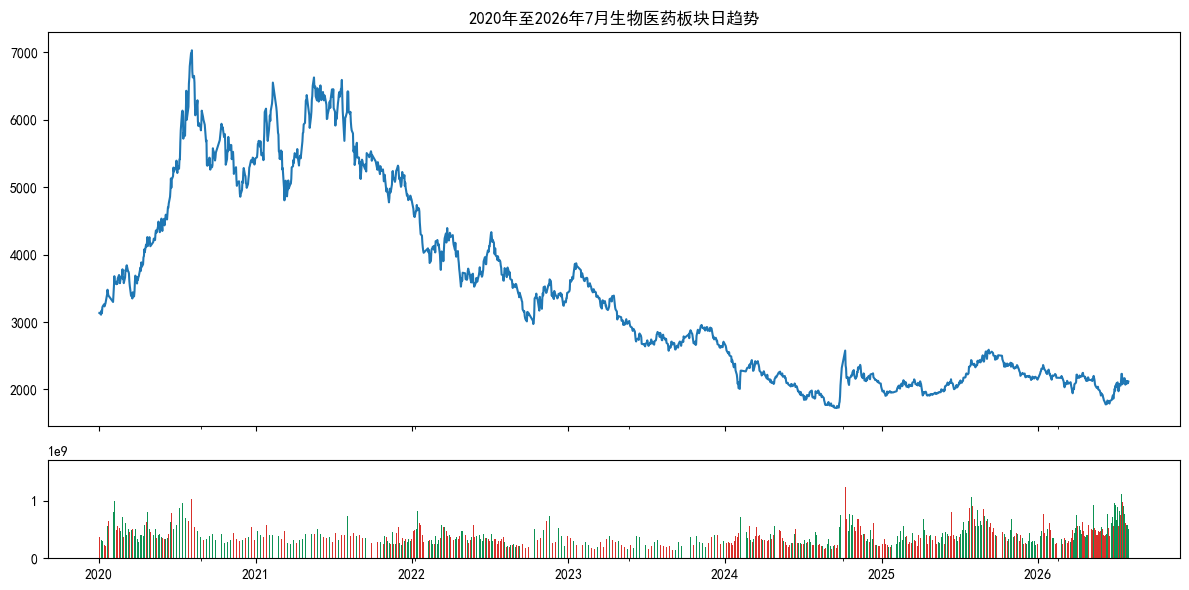

In [12]:
fig,axs = plt.subplots(2,1,sharex=True,figsize=(12,6),height_ratios=(4,1))
data['close'].plot(ax = axs[0])
axs[0].set_title('2020年至2026年7月生物医药板块日趋势')
colors = ['#0D9253' if c>o else '#D9302A' for c,o in zip(data['close'],data['open'])]
axs[1].bar(data.index,data['volume'].values,color=colors)

axs[1].xaxis.set_major_locator(mdates.AutoDateLocator())
axs[1].xaxis.set_major_formatter(mdates.AutoDateFormatter(axs[1].xaxis.get_major_locator())) # 根据数量自动调整标签
plt.tight_layout()
plt.savefig(r'../image/stock_price_trend.png')
plt.show()

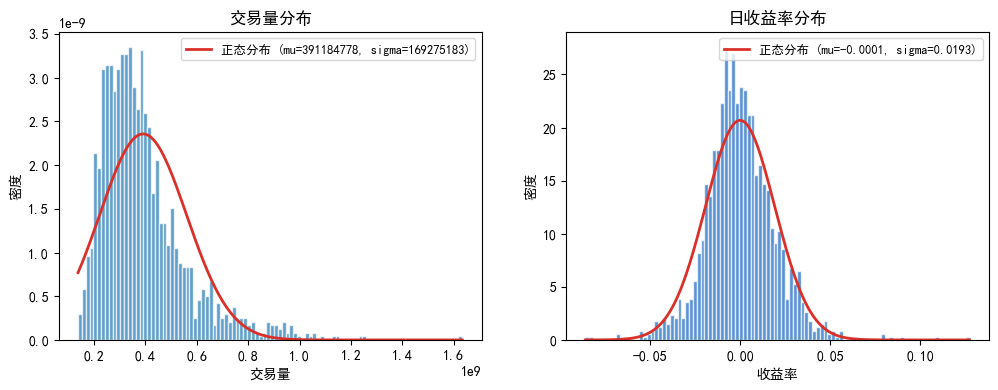

In [13]:
fig,(ax1,ax) = plt.subplots(1,2,figsize=(12,4))
dis_ = data['volume']
ax1.hist(dis_,bins=100,alpha=0.7,density=True,edgecolor='white')
mu1, sigma1 = dis_.mean(), dis_.std()
x1 = np.linspace(dis_.min(), dis_.max(), 200)
ax1.plot(x1, (1/(sigma1*np.sqrt(2*np.pi))) * np.exp(-0.5*((x1-mu1)/sigma1)**2),color='#D9302A', linewidth=2, \
        label=f'正态分布 (mu={mu1:.0f}, sigma={sigma1:.0f})')
ax1.set_title('交易量分布', fontsize=12, fontweight='bold')
ax1.set_xlabel('交易量')
ax1.set_ylabel('密度')
ax1.legend(fontsize=9)

data_diff = data['close'].pct_change().dropna()
ax.hist(data_diff,bins=100,color='#1565C0', alpha=0.7, density=True, edgecolor='white')
mu, sigma = data_diff.mean(), data_diff.std()
x = np.linspace(data_diff.min(), data_diff.max(), 200)
ax.plot(x, (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2),color='#D9302A', linewidth=2, \
        label=f'正态分布 (mu={mu:.4f}, sigma={sigma:.4f})')
ax.set_title('日收益率分布', fontsize=12, fontweight='bold')
ax.set_xlabel('收益率')
ax.set_ylabel('密度')
ax.legend(fontsize=9)
plt.savefig(r'../image/volume_returns_charts.png')
plt.show()

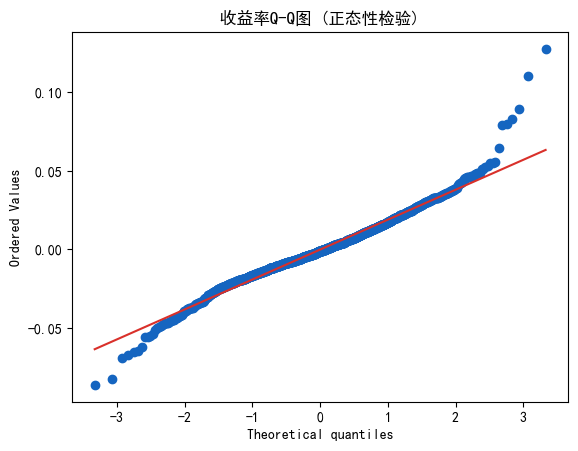

In [14]:
# Q-Q图 - 收益情况
fig,ax = plt.subplots()
stats.probplot(data_diff,dist='norm',plot=ax)
ax.set_title('收益率Q-Q图 (正态性检验)', fontsize=12, fontweight='bold')
ax.get_lines()[0].set_color('#1565C0')
ax.get_lines()[1].set_color('#D9302A')
plt.savefig(r'../image/qq_returns.png')
plt.show()

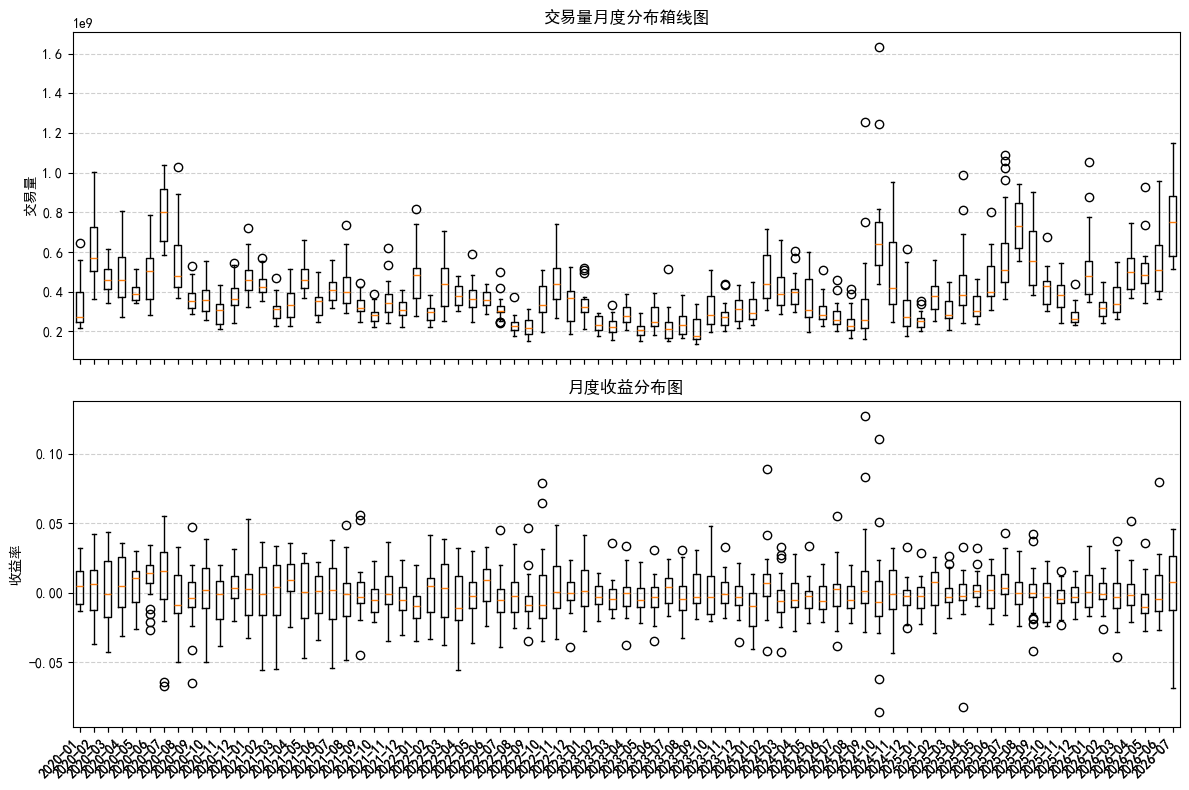

In [15]:
# 箱线图 判断是否有离群点
box_data = data[['volume','close']]
box_data['returns'] = data['close'].pct_change()
box_data.dropna(inplace=True)
box_data['month'] = pd.to_datetime(box_data.index).to_period("M")
months = box_data['month'].unique()

vol_data = []
ret_data = []
valid_months = []

for m in months:
    vol_vals = box_data[box_data['month'] == m]['volume'].dropna().values
    ret_vals = box_data[box_data['month'] == m]['returns'].dropna().values
    if len(vol_vals) > 0 and len(ret_vals) > 0:  # 确保非空
        vol_data.append(vol_vals)
        ret_data.append(ret_vals)
        valid_months.append(m)

fig,(ax1,ax2) = plt.subplots(2,1,sharex=True,figsize=(12,8))
ax1.boxplot(vol_data,labels=valid_months)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.set_title('交易量月度分布箱线图')
ax1.set_ylabel('交易量')

ax2.boxplot(ret_data,labels=valid_months)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.set_title('月度收益分布图')
ax2.set_ylabel('收益率')
# ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
# ax2.xaxis.set_major_formatter(mdates.AutoDateFormatter(axs[1].xaxis.get_major_locator()))
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.savefig(r'../image/volume_box.png')
plt.show()

In [16]:
# 孤立森林 对单变量使用，需 reshape
isolate = data['volume'].values.reshape(-1, 1)
iso_clf = IsolationForest(contamination=0.05)  # 预期异常比例
preds = iso_clf.fit_predict(isolate)  # 1正常，-1异常
data['anomaly'] = preds
# data[data['anomaly']==-1]

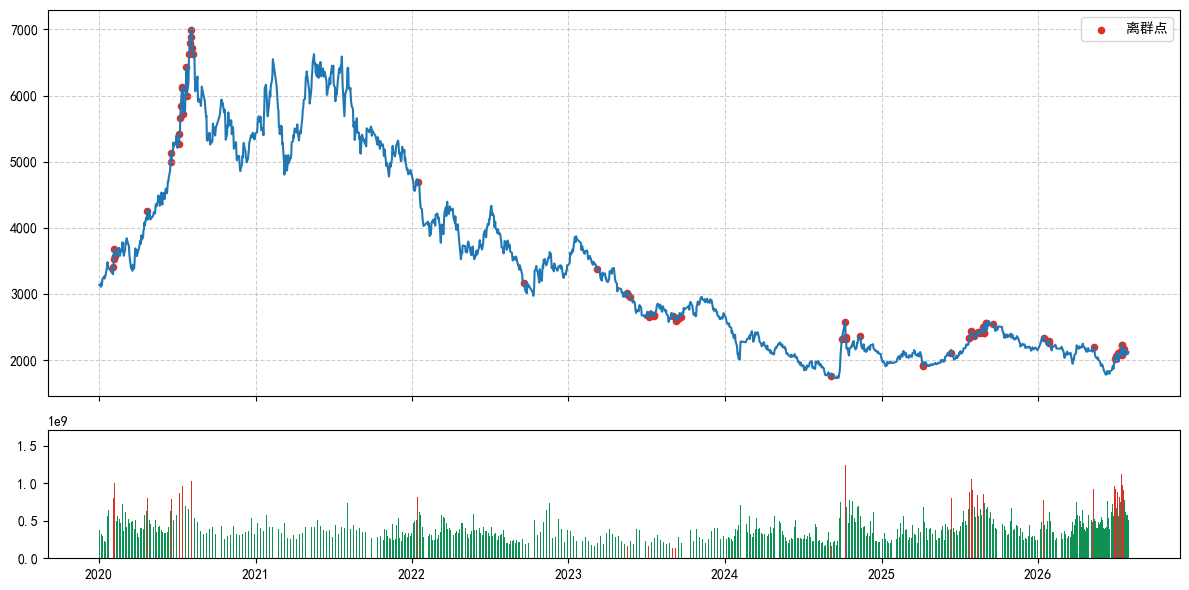

In [17]:
fig,axs = plt.subplots(2,1,sharex=True,figsize=(12,6),height_ratios=(3,1))
iso = data[data['anomaly']==-1]
axs[0].plot(data['close'])
axs[0].scatter(iso.index,iso['close'].values,color='#D9302A',s=20,label='离群点')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()
colors = ['#0D9253' if c>0 else '#D9302A' for c in data['anomaly'].values]
axs[1].bar(data.index,data['volume'].values,color = colors)
plt.tight_layout()
plt.savefig(r'../image/outliers.png')
plt.show()

### 按照95% 的置信区间检测出的点很好的落在出现转折信号附近

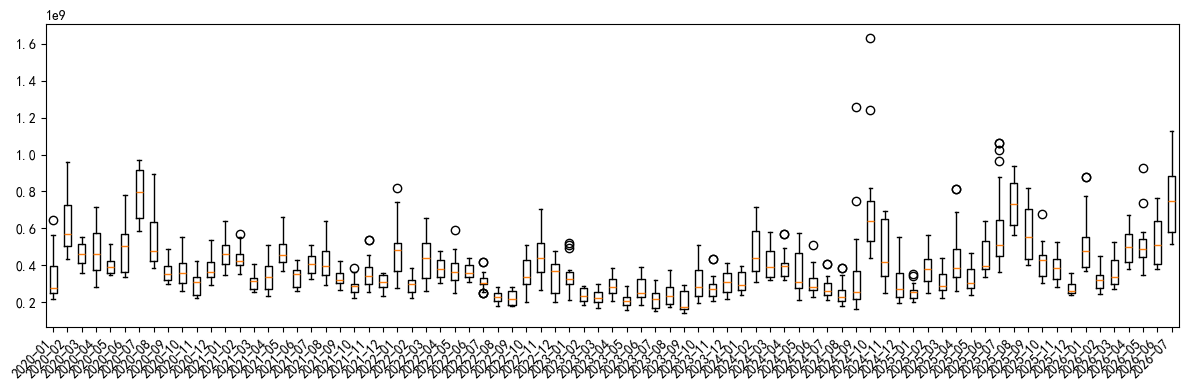

In [18]:
# 按月份分组并应用
isolate_data = box_data.copy()
isolate_data['month'] = box_data.index.to_period('M')
isolate_data['isolate'] = isolate_data.groupby(by='month')['volume'].transform(lambda x: stats.mstats.winsorize(x, limits=(0.05, 0.05)))
iso_data = [isolate_data[isolate_data['month']==m]['isolate'].dropna().values for m in months]
fig,ax = plt.subplots(figsize=(12,4))
ax.boxplot(iso_data,labels=months)
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

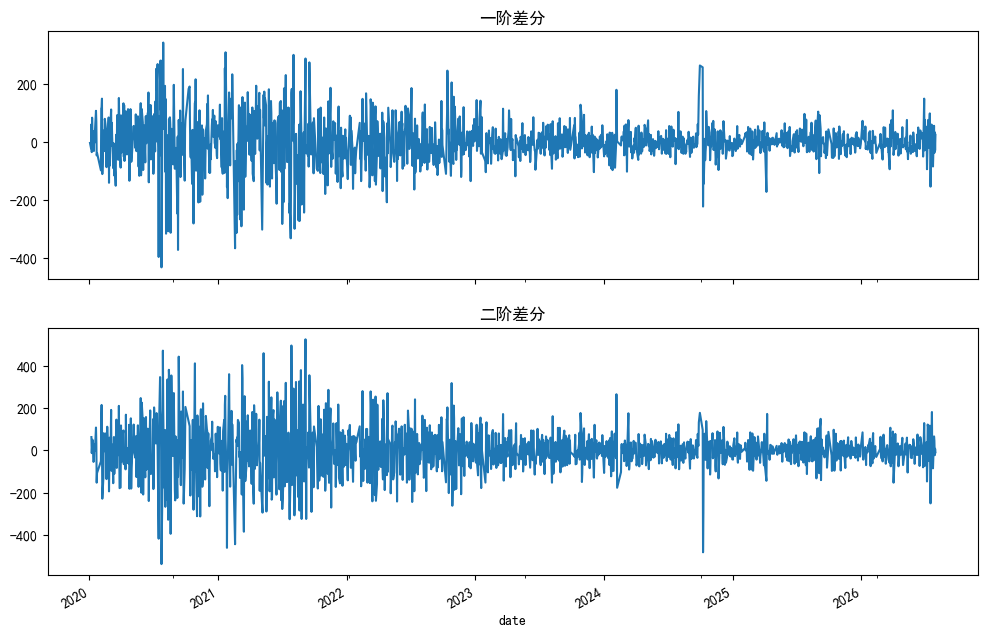

In [19]:
fig,axs = plt.subplots(2,1,sharex=True,figsize=(12,8))
diff_data = data['close'].diff(1).dropna()
diff_data.plot(ax=axs[0])
axs[0].set_title('一阶差分')
diff_data.diff(2).plot(ax=axs[1])
axs[1].set_title('二阶差分')
plt.show()

In [20]:
#STL时间序列分解
stl = STL(data['close'],period=22,robust=True)
stl_result = stl.fit()
trend = stl_result.trend
seasonal = stl_result.seasonal
residual = stl_result.resid

<Axes: xlabel='date'>

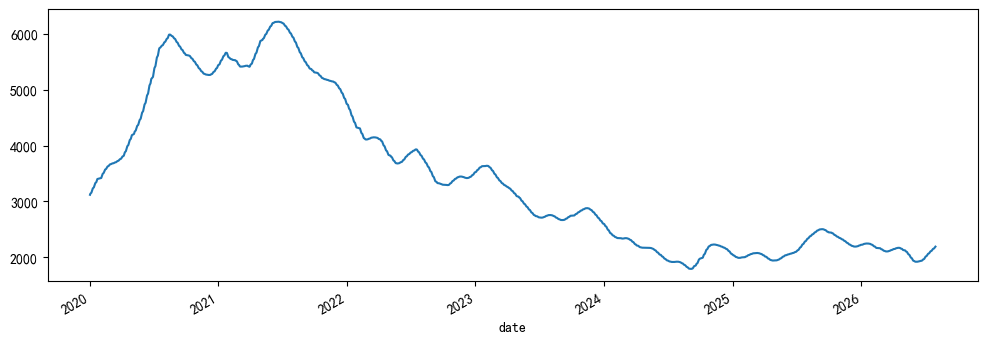

In [21]:
plt.figure(figsize=(12,4))
trend.plot()

### 从趋势图可以看出，指数在2022年初至2024年底呈现震荡下行的大趋势，随后自2025年起出现明显回升，并在2026年维持相对高位，之后快速下行。

<Axes: xlabel='date'>

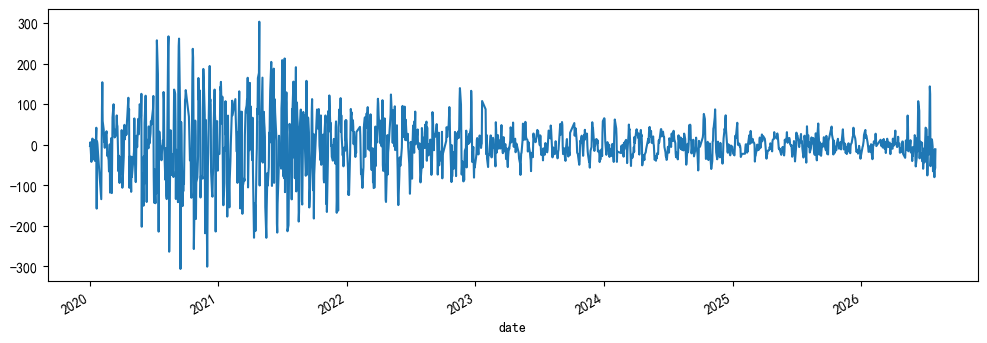

In [22]:
plt.figure(figsize=(12,4))
seasonal.plot()

### 季节图呈现有规律的波浪形起伏，说明指数存在短期的周期性波动，可能源于市场交易节奏（如月初/月末效应、财报季等）。由于股票日数据通常不存在严格的月度周期，实际季节性可能较弱，实际意义有限。

<Axes: xlabel='date'>

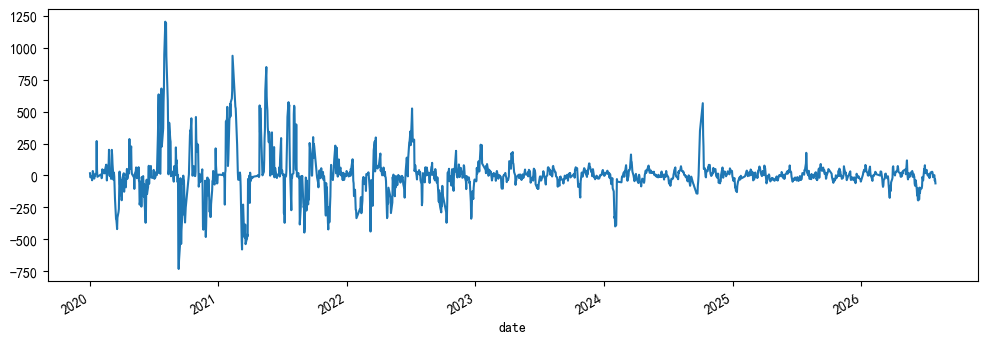

In [23]:
plt.figure(figsize=(12,4))
residual.plot()

### 残差图波动幅度较大且无明显规律，指数的日常波动大部分属于随机噪声，难以被趋势或周期完全解释。这也符合金融时间序列的典型特征——高波动性和低可预测性；残差占比高，说明价格受大量随机因素影响，预测难度大。

In [24]:
#分解质量：残差占比
ss_total=((data['close'] - data['close'].mean())**2).sum()
ss_residual = (residual**2).sum()
r_squred = 1-ss_residual/ss_total
print(f"分解拟合度: {r_squred}")

分解拟合度: 0.9868329532530465


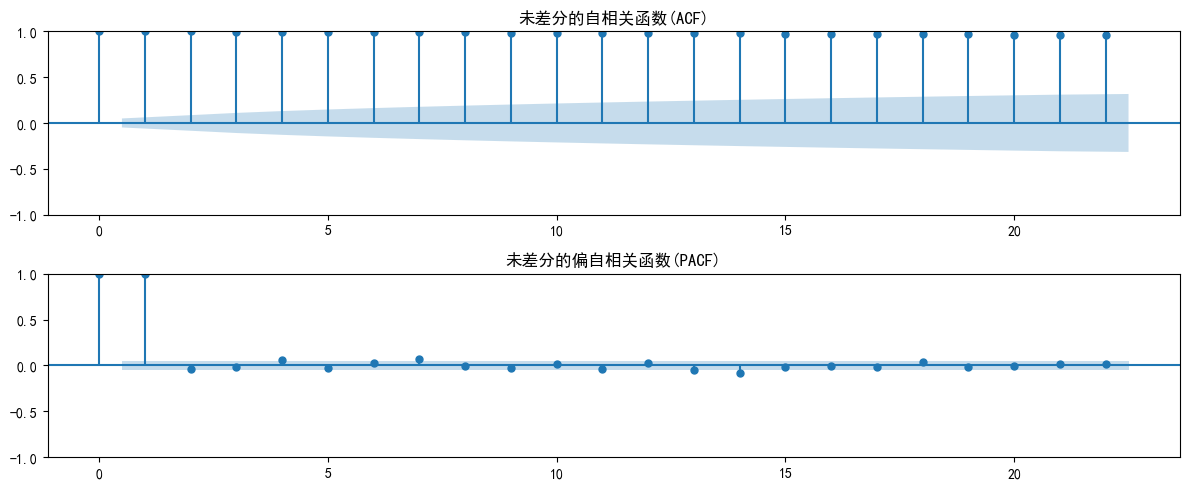

In [25]:
data_diff = data['close']
fig,axs = plt.subplots(2,1,figsize=(12,5))
plot_acf(data_diff,lags=22,alpha=0.05,ax=axs[0])
axs[0].set_title('未差分的自相关函数(ACF)')
plot_pacf(data_diff,lags=22,alpha=0.05,ax=axs[1])
axs[1].set_title('未差分的偏自相关函数(PACF)')
plt.tight_layout()
plt.savefig('../image/acf_pacf.png')
plt.show()

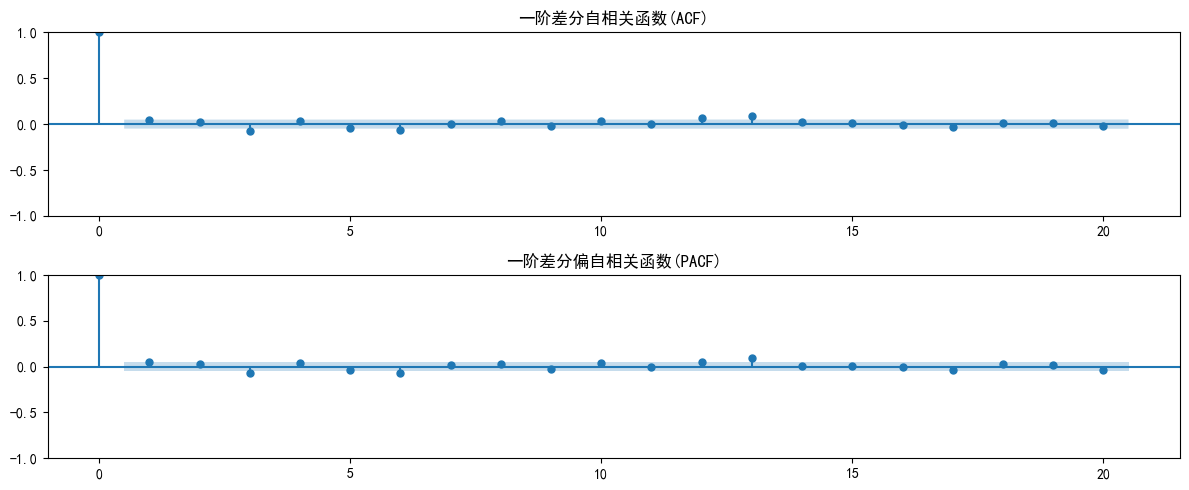

In [26]:
data_diff_1 = data['close'].diff().dropna()
fig,axs = plt.subplots(2,1,figsize=(12,5))
plot_acf(data_diff_1,lags=20,alpha=0.05,ax=axs[0])
axs[0].set_title('一阶差分自相关函数(ACF)')
plot_pacf(data_diff_1,lags=20,alpha=0.05,ax=axs[1])
axs[1].set_title('一阶差分偏自相关函数(PACF)')
plt.tight_layout()
plt.savefig('../image/acf_pacf_1.png')
plt.show()

In [27]:
def adf_test(series,name):
    result = adfuller(series.dropna(),autolag='AIC')
    labels=['统计量','p值','使用滞后阶数','观测数']
    critical = result[4]
    print(f"\n [------{name}-------]")
    for i,label in enumerate(labels):
        print(f"    {label}: {result[i]:.4f}")
    print('临界值: ')
    for key,val in critical.items():
        print(f"    {key}:{val:.4f}")
    if result[1]<=0.05:
        print(f"    结论: p={result[1]:.4f} ≤0.05 → 序列平稳   ✔")
    else:
        print(f"    结论: p={result[1]:.4f} >0.05 → 序列非平稳 ×")
    return result[1]

p_original = adf_test(data['close'],'原始序列')
p_diff1 = adf_test(data['close'].diff().dropna(),'一阶差分序列')
p_diff1_s22 = adf_test(data['close'].diff().diff(22).dropna(),'一阶差分+季节差分')


 [------原始序列-------]
    统计量: -1.0366
    p值: 0.7397
    使用滞后阶数: 13.0000
    观测数: 1580.0000
临界值: 
    1%:-3.4345
    5%:-2.8634
    10%:-2.5677
    结论: p=0.7397 >0.05 → 序列非平稳 ×

 [------一阶差分序列-------]
    统计量: -9.7170
    p值: 0.0000
    使用滞后阶数: 12.0000
    观测数: 1580.0000
临界值: 
    1%:-3.4345
    5%:-2.8634
    10%:-2.5677
    结论: p=0.0000 ≤0.05 → 序列平稳   ✔

 [------一阶差分+季节差分-------]
    统计量: -13.9326
    p值: 0.0000
    使用滞后阶数: 21.0000
    观测数: 1549.0000
临界值: 
    1%:-3.4346
    5%:-2.8634
    10%:-2.5678
    结论: p=0.0000 ≤0.05 → 序列平稳   ✔


In [28]:
# 模型构建与评估
# 划分训练集与测试集：最后三个月做测试（保留24个月训练满足HW的2个季节周期要求）
arma_data = data[-500:]
train_size = int(len(arma_data) * 0.9)
train = arma_data['close'][:train_size]
test = arma_data['close'][train_size:]
print(f"训练集: {train.index[0].strftime('%Y-%m-%d')} - {train.index[-1].strftime('%Y-%m-%d')} ( {len(train)} 天); ")
print(f"测试集: {test.index[0].strftime('%Y-%m-%d')} - {test.index[-1].strftime('%Y-%m-%d')} ( {len(test)} 天); ")

训练集: 2024-07-10 - 2026-05-21 ( 450 天); 
测试集: 2026-05-22 - 2026-07-31 ( 50 天); 


In [29]:
# 自动搜索最优SARIMA模型
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=22,
    # 非季节性参数范围 (p, d, q)
    start_p=0, max_p=4,       # 根据ACF/PACF分析，AR阶数可能不高
    start_q=0, max_q=4,       # 搜索MA阶数0-3
    d=True,                   # 让auto_arima自动检测最优差分阶数
    # 季节性参数范围 (P, D, Q)
    start_P=0, max_P=3,
    start_Q=0, max_Q=3,
    D=True,                   # 让auto_arima自动检测季节差分阶数，强制季节差分
    # 其他控制
    stepwise=True,            # 开启，否则搜索会非常慢
    trace=True,               # 开启，观察搜索过程
    maxiter=50,             # 限制迭代次数
)
print('-'*100)
# 查看最优模型的摘要
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,True,0)(0,True,0)[22]             : AIC=4628.634, Time=0.04 sec
 ARIMA(1,True,0)(1,True,0)[22]             : AIC=4513.412, Time=0.34 sec
 ARIMA(0,True,1)(0,True,1)[22]             : AIC=inf, Time=1.02 sec
 ARIMA(1,True,0)(0,True,0)[22]             : AIC=4621.749, Time=0.04 sec
 ARIMA(1,True,0)(2,True,0)[22]             : AIC=4479.173, Time=1.18 sec
 ARIMA(1,True,0)(3,True,0)[22]             : AIC=4457.382, Time=2.44 sec
 ARIMA(1,True,0)(3,True,1)[22]             : AIC=inf, Time=6.29 sec
 ARIMA(1,True,0)(2,True,1)[22]             : AIC=inf, Time=3.73 sec
 ARIMA(0,True,0)(3,True,0)[22]             : AIC=4463.392, Time=1.95 sec
 ARIMA(2,True,0)(3,True,0)[22]             : AIC=4458.924, Time=2.95 sec
 ARIMA(1,True,1)(3,True,0)[22]             : AIC=4459.160, Time=4.06 sec
 ARIMA(0,True,1)(3,True,0)[22]             : AIC=4457.173, Time=2.50 sec
 ARIMA(0,True,1)(2,True,0)[22]             : AIC=4479.205, Time=1.18 sec
 ARIMA(0,True,1)(3,True

In [30]:
auto_pre,conf_int = auto_model.predict(n_periods=len(test),return_conf_int=True,alpha=0.05)
mae = mean_absolute_error(test.values,auto_pre.values)
rmse = np.sqrt(mean_squared_error(test.values,auto_pre.values))
mape = np.mean(np.abs((test.values - auto_pre.values)/test.values)) * 100
print(f'SARIMAX > MAE = {mae:.2f}; MSE = {rmse:.2f}; MPAE={mape:.2f}%')

SARIMAX > MAE = 153.68; MSE = 170.32; MPAE=7.74%


#### 点预测误差较大

In [31]:
# Jarque-Bera (JB) 正态性检验,检验残差是否服从正态分布（原假设为正态分布）
train_residuals = auto_model.arima_res_.resid
test_residuals = test.values - auto_pre.values

# 对训练残差做检验
jb_stat, jb_pvalue = stats.jarque_bera(train_residuals.dropna())

print(f"Jarque-Bera 统计量: {jb_stat:.4f}")
print(f"P-value: {jb_pvalue:.4f}")

# 解读
if jb_pvalue > 0.05:
    print("✅ 无法拒绝正态性假设 (残差近似正态)")
else:
    print("⚠️ 拒绝正态性假设 (残差存在尖峰厚尾，在金融数据中非常常见)")

Jarque-Bera 统计量: 790190.8013
P-value: 0.0000
⚠️ 拒绝正态性假设 (残差存在尖峰厚尾，在金融数据中非常常见)


### 残差通过Ljung-Box自相关检验，表明信息提取充分；JB检验显著提示尖峰厚尾，后续预测区间应采用分位数回归或历史模拟法

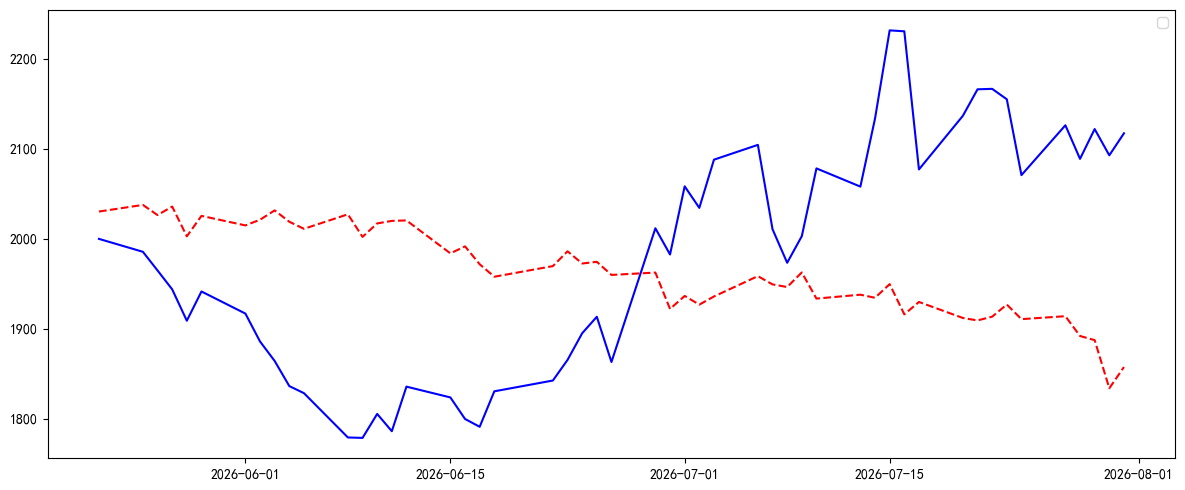

In [32]:
x = test.index
y1 = test.values
y2 = auto_pre.values
fig,ax = plt.subplots(figsize=(12,5))
ax.plot(x,y1,'b',x,y2,'r--')
ax.legend()
plt.tight_layout()
plt.show()

### 拟合效果不理想

In [33]:
# 基础特征
data['returns'] = data['close'].pct_change()
data['log_returns'] = np.log(data['close']/data['close'].shift(1))
data['amplitude'] = (data['high'] - data['low']) / data['close'].shift(1)
data['close_change'] = data['close'] - data['close'].shift(1)
data['close_pct'] = data['close'].pct_change()

In [34]:
# 移动平均线
for w in [5,10,20,60,120]:
    data[f'ma{w}'] = data['close'].rolling(w).mean()
    data[f'ma{w}_diff'] = data['close'] - data[f'ma{w}']

In [35]:
# MA金叉死叉信号
data['ma5_ma20_cross'] = np.where(data['ma5'] > data['ma20'],1,-1)
data['ma10_ma60_cross'] = np.where(data['ma10'] > data['ma60'],1,-1)

In [36]:
# 指数移动平均
for w in [5,12,26]:
    data[f'ema{w}'] = data['close'].ewm(span=w, adjust=False).mean()

# MACD
data['dif'] = data['ema12'] - data['ema26']
data['dea'] = data['dif'].ewm(span=9, adjust=False).mean()
data['macd'] = 2*(data['dea'] - data['dif'])

In [37]:
# RSI
for period in [6,14,24]:
    delta = data['close'].diff()
    gain = delta.where(delta > 0,0).rolling(period).mean()
    loss = (-delta.where(delta < 0,0)).rolling(period).mean()
    rs = gain/(loss + 1e-10)
    data[f'rsi{period}'] = 100 - (100/(1+rs))

In [38]:
# 布林带
for w in [20]:
    mid = data['close'].rolling(w).mean()
    std = data['close'].rolling(w).std()
    data[f'boll_upper_{w}'] = mid + 2 * std
    data[f'boll_lower_{w}'] = mid - 2 * std
    data[f'boll_width_{w}'] = (data[f'boll_upper_{w}'] - data[f'boll_lower_{w}'])/mid
    data[f'boll_pos_{w}'] = (data['close'] - data[f'boll_lower_{w}'])/(data[f'boll_upper_{w}'] - data[f'boll_lower_{w}'] + 1e-10)

In [39]:
# ATR 平均真实波动幅度
tr = pd.DataFrame(
    {'hl': data['high'] - data['low'],'hc': abs(data['high'] - data['close'].shift(1)),'lc':abs(data['low'] - data['close'].shift(1))}
).max(axis=1)
data['atr14'] = tr.rolling(14).mean()
data['art14_pct'] = data['atr14']/data['close']

In [40]:
# 成交量特征
data['vol_ma5'] = data['volume'].rolling(5).mean()
data['vol_ma20'] = data['volume'].rolling(20).mean()
data['vol_ratio'] = data['volume']/(data['vol_ma5'] + 1e-10)
data['vol_change'] = data['volume'].pct_change()
data['obv'] = (np.sign(data['close'].diff()) * data['volume']).fillna(0).cumsum()

In [41]:
# 动量特征
for w in [5,10,20]:
    data[f'momentum_{w}'] = data['close'] / data['close'].shift(w) - 1

In [42]:
# 波动率
for w in [5,20,60]:
    data[f'volatility_{w}'] = data['returns'].rolling(w).std()

# 滞后特征
for w in [1,2,3,5,10,20]:
    data[f'close_lag{w}'] = data['close'].shift(w)
    data[f'returns_lag{w}'] = data['returns'].shift(w)

In [43]:
# 价格形态
data['upper_shadow'] = data['high'] - data[['open','close']].max(axis=1)
data['lower_shadow'] = data[['open','close']].min(axis=1) - data['low']
data['body'] = abs(data['close'] - data['open'])
data['body_pct'] = (data['close'] - data['open'])/data['open']
data.dropna(inplace=True)

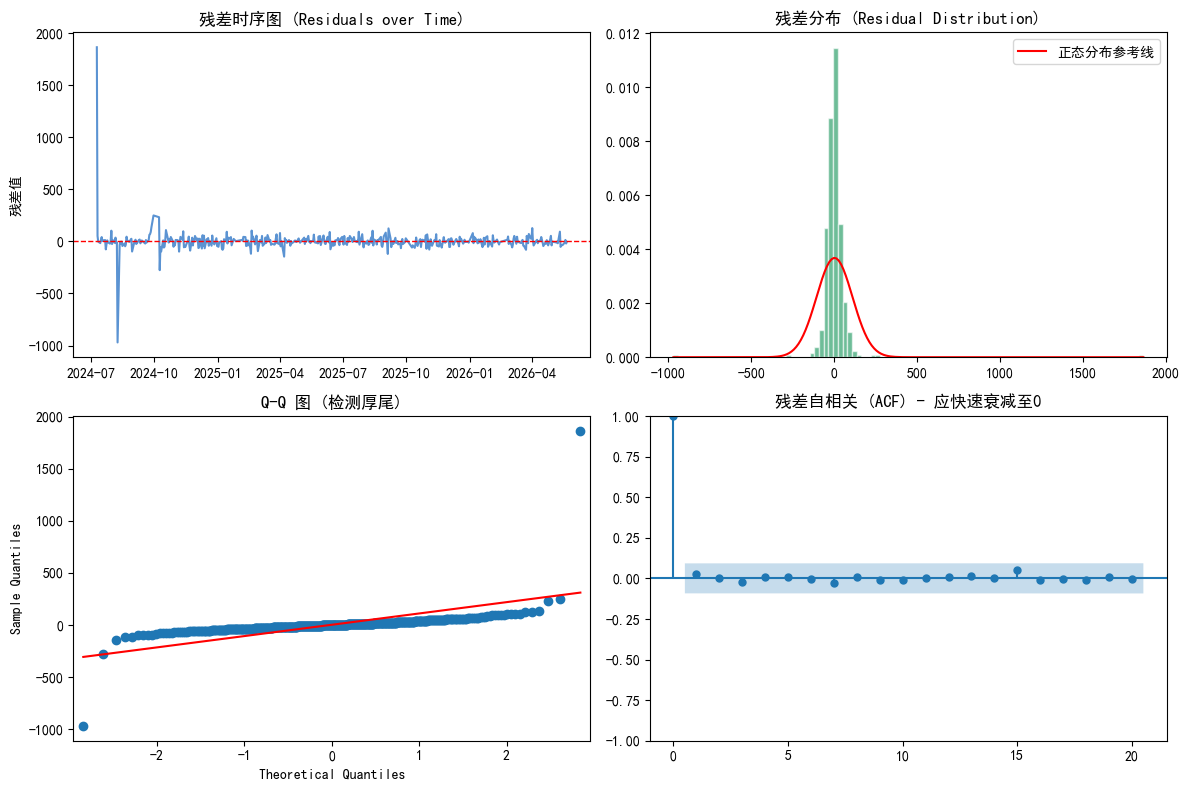

In [44]:
# 残差检验
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
resid_clean = train_residuals.dropna()

# 子图1: 残差时序图 (检查均值和方差的稳定性)
axes[0, 0].plot(resid_clean, color='#1565C0', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('残差时序图 (Residuals over Time)')
axes[0, 0].set_ylabel('残差值')

# 子图2: 残差直方图 + 核密度曲线
axes[0, 1].hist(resid_clean, bins=100, density=True, alpha=0.6, color='#0D9253', edgecolor='white')
# 叠加正态分布曲线对比
mu, std = np.mean(resid_clean), np.std(resid_clean)
x = np.linspace(resid_clean.min(), resid_clean.max(), 200)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, std), 'r-', label='正态分布参考线')
axes[0, 1].set_title('残差分布 (Residual Distribution)')
axes[0, 1].legend()

# 子图3: Q-Q 图 (Quantile-Quantile) - 检查尾部特征
sm.qqplot(resid_clean, line='s', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q 图 (检测厚尾)')

# 子图4: 残差自相关函数 (ACF) —— 决定性指标
plot_acf(resid_clean, ax=axes[1, 1], lags=20, alpha=0.05)
axes[1, 1].set_title('残差自相关 (ACF) - 应快速衰减至0')

plt.tight_layout()
plt.savefig(r'../image/residual.png')
plt.show()

## 残差时序图
#### 残差大致围绕零均值上下波动，无明显单调趋势或周期性，说明模型对趋势和季节性的拟合基本合理。
#### 但残差的波动幅度并非恒定，某些时段波动明显增大（如2026年后），表明可能存在波动聚集效应（条件异方差），这是金融时间序列的常见特征，也暗示后续可引入GARCH类模型。
#### 没有出现明显的异常离群点持续偏离，说明模型整体稳定
## 直方分布图
#### 直方图显示残差分布中心较高、尾部较厚，相对于正态曲线呈现尖峰厚尾形态。
#### 这说明残差不服从正态分布，与Jarque-Bera检验（p≈0）结果一致。金融收益率的残差通常具有这种特征，属于正常现象，但意味着基于正态假设的预测区间会偏窄，后续可采用分位数回归或历史模拟法进行区间预测。
## QQ图
#### 图中点在中部大致沿直线分布，但在两端（尤其是尾部）明显偏离直线，左尾下偏、右尾上偏，进一步证实了厚尾特征。
#### 这再次确认残差非正态，但Q-Q图对尾部偏差更敏感，有助于判断极端值风险。
## 残差自相关
#### 绝大多数滞后的自相关系数都落在95%置信区间内（蓝色区域），且无显著超出边界的值。
#### 结合Ljung-Box检验（Q统计量p≈0.97），说明残差序列不存在显著自相关，即模型已经充分提取了数据中的线性相关性，残差表现为白噪声。
#### 这是模型诊断中最重要的指标，表明ARIMA结构设定合理，信息提取充分。

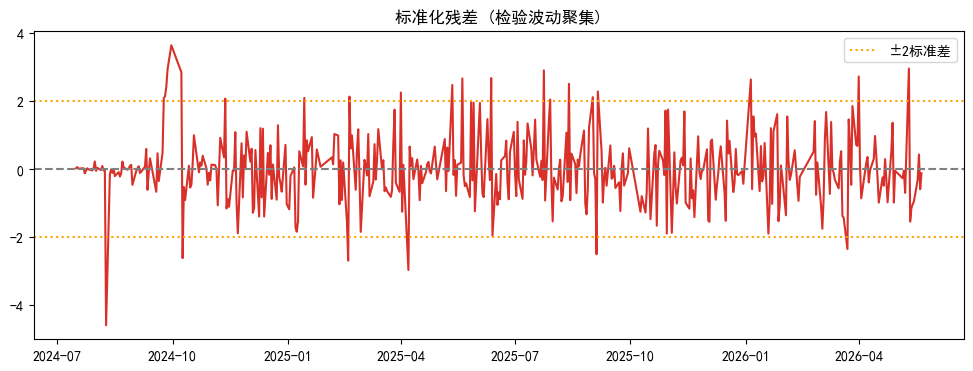

In [45]:
# 计算残差的滚动标准差 (窗口22天)
rolling_std = resid_clean.rolling(22, min_periods=5).std()
std_resid = resid_clean / rolling_std

plt.figure(figsize=(12, 4))
plt.plot(std_resid, color='#D9302A')
plt.axhline(y=0, linestyle='--', color='gray')
plt.axhline(y=2, linestyle=':', color='orange', label='±2标准差')
plt.axhline(y=-2, linestyle=':', color='orange')
plt.title('标准化残差 (检验波动聚集)')
plt.legend()
plt.savefig(r'../image/residual_normal.png')
plt.show()

### 明数据存在条件异方差效应，这是引入GARCH模型的有力信号。

In [46]:
# 引入GARCH模型
# 放大残差以改善数值稳定性
scaled_residuals = resid_clean * 100

# 拟合GARCH(1,1) with t分布
garch_model = arch_model(
    scaled_residuals,
    mean='Zero',
    vol='Garch',
    p=1, q=1,
    dist='t'
)
garch_result = garch_model.fit(disp='off')
garch_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Zero Mean - GARCH Model Results                           
====================================================================================
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                            GARCH   Log-Likelihood:               -4421.61
Distribution:      Standardized Student's t   AIC:                           8851.21
Method:                  Maximum Likelihood   BIC:                           8867.65
                                              No. Observations:                  450
Date:                      Wed, Aug 26 2026   Df Residuals:                      450
Time:                              14:42:37   Df Model:                            0
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      2.3569e+06  9.552e+05      2.468  1.360e-02 [4.849e+05,4.229e+06]
alpha[1]       0.3017      0.263      1.145      0.252     [ -0.215,  0.818]
beta[1]        0.5959      0.166      3.592  3.288e-04     [  0.271,  0.921]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.1845      1.032      4.056  4.990e-05 [  2.162,  6.207]
========================================================================

Covariance estimator: robust
"""

In [47]:
garch_result.params

omega       2.356942e+06
alpha[1]    3.016742e-01
beta[1]     5.959155e-01
nu          4.184498e+00
Name: params, dtype: float64

#### 参数显著性：ω、β₁、ν 的 p 值都小于 0.05，估计显著。

#### 波动持续性：α + β = 0.3016742 + 0.5959155 = 0.89759，小于 1，满足平稳性条件，表明波动冲击以较慢速度衰减。

#### 自由度 ν = 4.18，明显小于正态分布（ν→∞），说明残差尾部较厚，采用 t 分布是合理的。

In [48]:
# ---------- 诊断 ----------
std_resid = garch_result.resid / garch_result.conditional_volatility
print(acorr_ljungbox(std_resid.dropna(), lags=10))
alpha = garch_result.params['alpha[1]']
beta = garch_result.params['beta[1]']
print(f"α+β = {alpha + beta:.4f}")  # 接近1 → 波动持续性强

     lb_stat  lb_pvalue
1   0.002598   0.959353
2   0.021723   0.989197
3   0.420077   0.936065
4   0.434725   0.979536
5   0.525892   0.991145
6   0.639411   0.995707
7   3.208699   0.865048
8   3.209110   0.920557
9   3.661255   0.932262
10  3.793303   0.956190
α+β = 0.8976


#### 所有 p 值都很大（>0.8），表明残差序列已无显著自相关，均值方程（这里是零均值）已充分捕捉线性关系

In [49]:
# ---------- 组合预测 ----------
sarima_forecast = auto_pre.values
garch_forecast = garch_result.forecast(horizon=len(test))
conditional_vol = np.sqrt(garch_forecast.variance.iloc[-1].values)/100

nu = garch_result.params['nu']
t_crit = t.ppf(0.975, df=nu)

upper = sarima_forecast + t_crit * conditional_vol
lower = sarima_forecast - t_crit * conditional_vol

# ---------- 评估动态置信区间覆盖率 ----------
coverage = np.mean((test.values >= lower) & (test.values <= upper))
print(f"动态置信区间覆盖率: {coverage:.2%}")

动态置信区间覆盖率: 38.00%


#### 覆盖率仅为 38%，远低于 95% 的理论值。模型对预测区间严重低估，存在以下可能原因：

    预测的不确定性被低估：GARCH 预测的波动率可能偏小，特别是在测试集波动率突然增大时。

    参数估计不确定性被忽略：只使用了点估计，没有考虑参数的抽样变异性（可通过 bootstrap 或贝叶斯方法弥补）。

    分布的尾部可能仍不够厚：虽然使用了 t 分布，但自由度 ν≈4.18 不算特别小，对于极端波动可能仍不足。

    SARIMA 点预测误差的分布可能并非零均值：均值模型是零均值，但 SARIMA 预测误差可能具有非零均值或异方差。

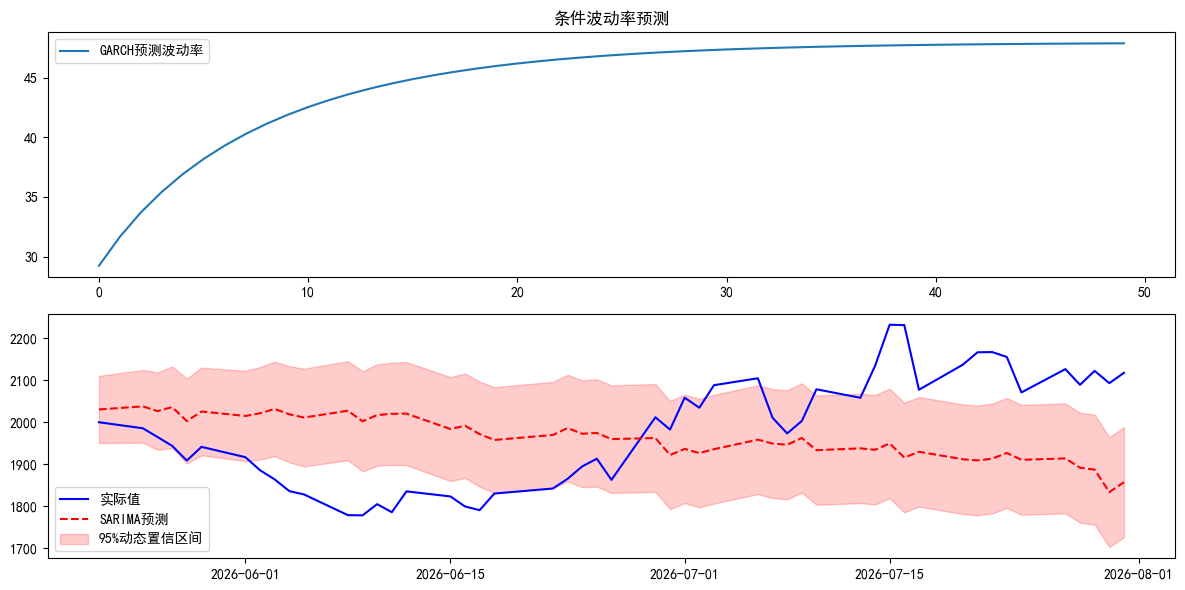

In [50]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 子图1：波动率预测
axes[0].plot(conditional_vol, label='GARCH预测波动率')
axes[0].set_title('条件波动率预测')
axes[0].legend()

# 子图2：带动态置信区间的预测
axes[1].plot(test.index, test.values, 'b-', label='实际值')
axes[1].plot(test.index, sarima_forecast, 'r--', label='SARIMA预测')
axes[1].fill_between(test.index, lower, upper, 
                     alpha=0.2, color='red', label='95%动态置信区间')
axes[1].legend()
plt.tight_layout()
plt.savefig(r'../image/volatility_arma.png')
plt.show()

In [51]:
# 特征相关性
corr = data.corr()
corr = corr['close'].sort_values(ascending=False)
corr = corr[abs(corr)>0.2]

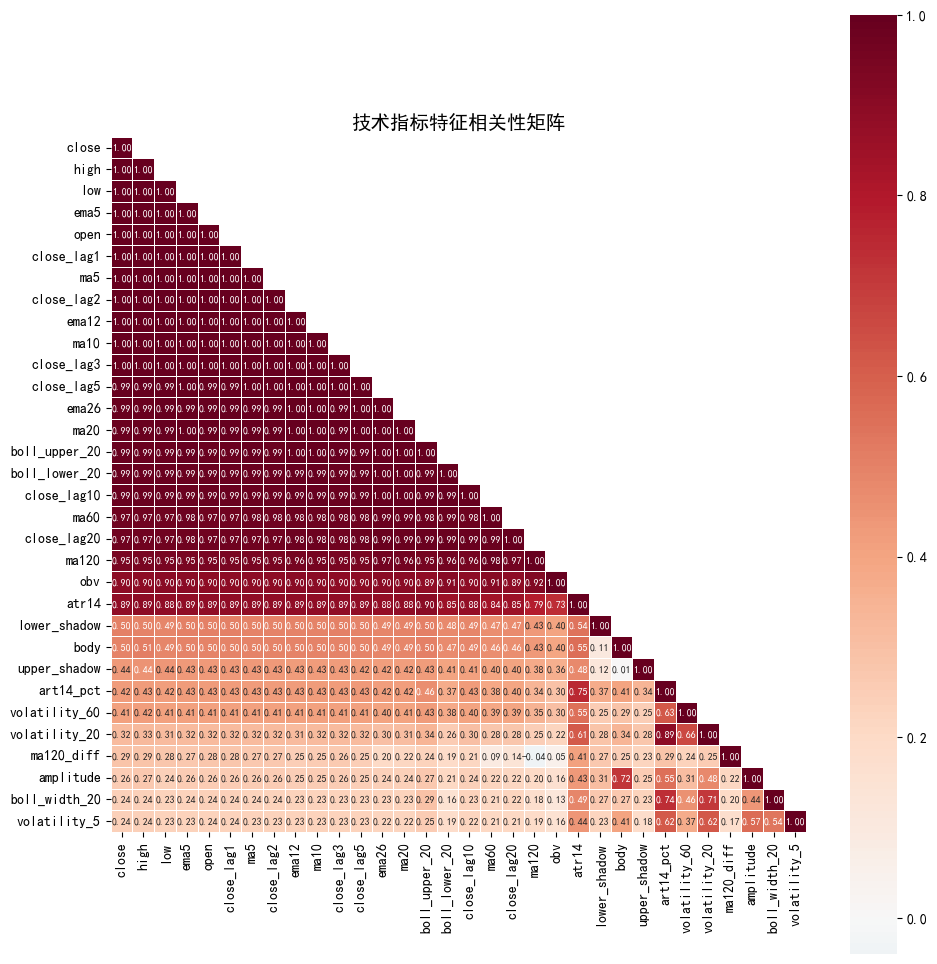

In [52]:
# 绘制热力图
cols_fea = [x for x in corr.index]
plt.figure(figsize=(10,10))
corr = data[cols_fea].corr()
mask = np.triu(np.ones_like(corr,dtype=bool),k = 1)
sns.heatmap(corr,mask=mask,annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,linewidths=0.5,annot_kws={'size':7})
plt.title('技术指标特征相关性矩阵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../image/feature_correlation.png', bbox_inches='tight')
plt.show()

## 多变量

In [53]:
# 平稳性检验
def adf_test(series,name):
    result = adfuller(series,autolag="AIC")
    return {
        'name': name,
        'statistic': result[0],
        'p_value': result[1],
        'critical_1%': result[4]['1%'],
        'critical_5%': result[4]['5%'],
        'critical_10%': result[4]['10%'],
        'stationary': result[1] < 0.05
           }

In [54]:
# 平稳性检验-原始序列
val_data = data[['close', 'volume', 'rsi14', 'boll_width_20', 'volatility_20']].copy()
adf_results_original = []
for col in val_data.columns:
    adf_results_original.append(adf_test(val_data[col],col))
adf_results_original = pd.DataFrame(adf_results_original)
adf_results_original

,name,statistic,p_value,critical_1%,critical_5%,critical_10%,stationary
0,close,-1.794704,3.830943e-01,-3.434834,-2.863520,-2.567824,False
1,volume,-5.361925,4.070091e-06,-3.434828,-2.863518,-2.567823,True
2,rsi14,-7.594921,2.474938e-11,-3.434862,-2.863533,-2.567831,True
3,boll_width_20,-8.746336,2.915942e-14,-3.434800,-2.863505,-2.567816,True
4,volatility_20,-4.764936,6.343855e-05,-3.434868,-2.863535,-2.567832,True


#### 原始序列close为非平稳序列

In [55]:
# 一阶差分序列
val_data_diff = val_data.diff().dropna()
adf_results_diff = []
for col in val_data_diff.columns:
    adf_results_diff.append(adf_test(val_data_diff[col],col))
adf_results_diff = pd.DataFrame(adf_results_diff)
adf_results_diff

,name,statistic,p_value,critical_1%,critical_5%,critical_10%,stationary
0,close,-10.139306,8.503585e-18,-3.434834,-2.863520,-2.567824,True
1,volume,-16.226410,3.851011e-29,-3.434828,-2.863518,-2.567823,True
2,rsi14,-14.711131,2.846384e-27,-3.434837,-2.863522,-2.567825,True
3,boll_width_20,-12.110039,1.928795e-22,-3.434855,-2.863530,-2.567829,True
4,volatility_20,-14.098635,2.642811e-26,-3.434855,-2.863530,-2.567829,True


### 格兰杰因果试验

In [56]:
granger_result = {}
target_col = 'close'
for col in val_data_diff.columns:
    if col == target_col:
        continue
    try:
        test_result = grangercausalitytests(val_data_diff[[target_col,col]].dropna(),maxlag=5,verbose=False)
        min_p = min(test_result[i][0]['ssr_ftest'][1] for i in range(1,6))
        best_lag = min(range(1,6),key=lambda i:test_result[i][0]['ssr_ftest'][1])
        granger_result[col] = {'min_p_value':min_p, 'best_lag':best_lag, 'causes':min_p < 0.05}
    except Exception as e:
        granger_result[col] = {'error': str(e)}
granger_result

{'volume': {'min_p_value': 0.3680543559415548, 'best_lag': 1, 'causes': False},
 'rsi14': {'min_p_value': 0.23107847824473107, 'best_lag': 3, 'causes': False},
 'boll_width_20': {'min_p_value': 0.018312098142648836,
  'best_lag': 3,
  'causes': True},
 'volatility_20': {'min_p_value': 0.12374772617036081,
  'best_lag': 1,
  'causes': False}}

In [90]:
print('|NAME|MIN_P_VALUE|BEST_LAG|CAUSES|')
print('|----|-----------|--------|------|')
for key, value in granger_result.items():
    print(f"|{key:>15s}|{value['min_p_value']:>11.2f}|{value['best_lag']:>9.1f}|{value['causes']:>6.2f}|")

|NAME|MIN_P_VALUE|BEST_LAG|CAUSES|
|----|-----------|--------|------|
|         volume|       0.37|      1.0|  0.00|
|          rsi14|       0.23|      3.0|  0.00|
|  boll_width_20|       0.02|      3.0|  1.00|
|  volatility_20|       0.12|      1.0|  0.00|


In [57]:
# 进行Johansen协整性检验
coint_result = coint_johansen(val_data,det_order=0,k_ar_diff=2)
# 迹检验和最大特征检验
coint_trace = coint_result.lr1 # 迹统计量
coint_trace_crit = coint_result.cvt # 临界值[90%, 95%, 99%]
coint_maxeig = coint_result.lr2 # 最大特征统计量
coint_maxeig_crit = coint_result.cvm # 临界值
n_vars = len(val_data.columns)

# 判定协整阶数
coint_rank_trace = 0
for i in range(n_vars):
    if coint_trace[i]>coint_trace_crit[i,1]: # 95%临界值
        coint_rank_trace = i +1
    else:
        break
coint_rank_maxeig = 0
for i in range(n_vars):
    if coint_maxeig[i]>coint_maxeig_crit[i,1]: # 95%临界值
        coint_rank_maxeig = i +1
    else:
        break
coint_rank = max(coint_rank_trace,coint_rank_maxeig)
coint_rank

4

In [58]:
# 协整秩上限 = n_vars - 1 (满秩意味着所有序列平稳, 与ADF结论矛盾, 不可信)
coint_rank = min(coint_rank,n_vars - 1)
has_cointegration = coint_rank > 0
print(f"  协整秩(迹检验)={coint_rank_trace}, 协整秩(最大特征值)={coint_rank_maxeig}, 取={coint_rank}")
print(f"  存在协整关系: {has_cointegration}")

  协整秩(迹检验)=4, 协整秩(最大特征值)=4, 取=4
  存在协整关系: True


#### 针对格兰杰因果检验结果，进行多重比较校正以避免因多次检验而增加假阳性风险（Familywise Error Rate, FWER）

In [59]:
p_values = [v['min_p_value'] for v in granger_result.values() if 'min_p_value' in v]
variables = [k for k, v in granger_result.items() if 'min_p_value' in v]

# 应用 BH 校正（fdr_bh）和 Bonferroni
reject_bh, pvals_corrected_bh, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
reject_bonf, pvals_corrected_bonf, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# 输出结果
for var, p_raw, rej_bh, rej_bonf, corr_bh in zip(variables, p_values, reject_bh, reject_bonf, pvals_corrected_bh):
    print(f"{var}: raw p={p_raw:.4f}, BH adj p={corr_bh:.4f}, BH reject={rej_bh}, Bonferroni reject={rej_bonf}")

volume: raw p=0.3681, BH adj p=0.3681, BH reject=False, Bonferroni reject=False
rsi14: raw p=0.2311, BH adj p=0.3081, BH reject=False, Bonferroni reject=False
boll_width_20: raw p=0.0183, BH adj p=0.0732, BH reject=False, Bonferroni reject=False
volatility_20: raw p=0.1237, BH adj p=0.2475, BH reject=False, Bonferroni reject=False


In [60]:
val_data_diff.corr()

,close,volume,rsi14,boll_width_20,volatility_20
close,1.000000,0.195348,0.557217,0.043855,0.034554
volume,0.195348,1.000000,0.177327,0.141888,0.245258
rsi14,0.557217,0.177327,1.000000,-0.016499,0.066474
boll_width_20,0.043855,0.141888,-0.016499,1.000000,0.233869
volatility_20,0.034554,0.245258,0.066474,0.233869,1.000000


#### 两种校正均支持同一结论：仅有 volatility_20 在统计上显著地 Granger 引起收盘价，其最优滞后阶数为 2。

#### 校正后波动率的 p 值仍显著，说明该结果稳健，并非多重比较导致的假阳性。

#### 其他变量（volume、rsi14、macd、boll_width_20）即使不校正也不显著，校正后更不显著，可忽略。

### 拟合多变量模型

In [61]:
var_model = VAR(val_data_diff)
lag_order = var_model.select_order(maxlags=15)
optimal_lag = lag_order.aic
print(f"  最优滞后阶数(AIC): {optimal_lag}")

  最优滞后阶数(AIC): 14


In [62]:
# var 预测（差分空间）
var_result = var_model.fit(optimal_lag)
forecast = var_result.forecast(val_data_diff.values[-optimal_lag:],steps=20)

In [63]:
# 反差分还原
last_close = val_data['close'].iloc[-1]
var_forecast = []
current_close = last_close
for i in range(20):
    current_close += forecast[i, 0]
    var_forecast.append(current_close)

In [64]:
lag_order.summary()

,AIC,BIC,FPE,HQIC
0,26.46,26.48,3.108e+11,26.47
1,25.50,25.61*,1.188e+11,25.54
2,25.44,25.64,1.114e+11,25.51
3,25.42,25.71,1.097e+11,25.53
4,25.42,25.80,1.097e+11,25.56
5,25.43,25.90,1.104e+11,25.60
6,25.41,25.97,1.084e+11,25.62
7,25.42,26.08,1.100e+11,25.67
8,25.42,26.16,1.099e+11,25.70
9,25.43,26.26,1.103e+11,25.74


In [65]:
var_result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 26, Aug, 2026
Time:                     14:42:40
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    25.9636
Nobs:                     1460.00    HQIC:                   25.1578
Log likelihood:          -28018.4    FPE:                5.22164e+10
AIC:                      24.6783    Det(Omega_mle):     4.11808e+10
--------------------------------------------------------------------
Results for equation close
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                    -3.398971         1.972011           -1.724           0.085
L1.close                  0.039535         0.032672            1.210           0.226
L1.volume                 0.000000         0

In [66]:
backtest_steps = 50
train_diff = val_data_diff.iloc[:-backtest_steps]
train_model = VAR(train_diff)
train_fit = train_model.fit(optimal_lag)
backtest_fc_diff = train_fit.forecast(train_diff.values[-optimal_lag:], steps=backtest_steps)

# 反差分还原
train_last_close = val_data['close'].iloc[-(backtest_steps+1)]
backtest_pred = []
cc = train_last_close
for i in range(backtest_steps):
    cc += backtest_fc_diff[i, 0]
    backtest_pred.append(cc)

actual_test = val_data['close'].iloc[-backtest_steps:].values
var_mae = mean_absolute_error(actual_test, backtest_pred)
var_rmse = np.sqrt(mean_squared_error(actual_test, backtest_pred))
var_mape = np.mean(np.abs((actual_test - backtest_pred) / actual_test)) * 100
{'mae': var_mae, 'rmse': var_rmse, 'mape': var_mape}
print(f"  VAR回测 MAPE={var_mape:.2f}%; mae= {var_mae:.4f}, rmse= {var_rmse:.4f}")

  VAR回测 MAPE=7.49%; mae= 149.3578, rmse= 166.8636


In [67]:
# Johansen检验显示协整关系存在 引入VECM 模型
# --- VECM模型 (如果存在协整关系) ---
vecm_forecast = None
vecm_backtest_metrics = None
if has_cointegration:
    print(f"  检测到协整关系(Johansen rank={coint_rank}), 尝试VECM模型 ...")
    # Johansen在金融数据上常高估秩, 从rank=1开始逐步尝试取第一个稳定的
    for try_rank in range(1, coint_rank + 1):
        try:
            print(f"    尝试 VECM rank={try_rank} ...")
            vecm_model = VECM(
                val_data,
                k_ar_diff=optimal_lag,
                coint_rank=try_rank,
                deterministic='ci'  # 协整空间内常数, 更稳定
                )
            vecm_fit = vecm_model.fit()

            # VECM回测
            train_vecm = val_data.iloc[:-backtest_steps]
            vecm_bt_model = VECM(train_vecm, k_ar_diff=optimal_lag, coint_rank=try_rank, deterministic='ci')
            vecm_bt_fit = vecm_bt_model.fit()
            vecm_bt_pred_raw = vecm_bt_fit.predict(steps=backtest_steps)
            vecm_bt_pred = vecm_bt_pred_raw[:, 0]
            vecm_mae = mean_absolute_error(actual_test, vecm_bt_pred)
            vecm_rmse = np.sqrt(mean_squared_error(actual_test, vecm_bt_pred))
            vecm_mape = np.mean(np.abs((actual_test - vecm_bt_pred) / actual_test)) * 100

            if vecm_mape > 10 or np.isnan(vecm_mape) or np.isinf(vecm_mape):
                print(f"    rank={try_rank} MAPE={vecm_mape:.2f}% (不稳定, 继续降秩)")
                continue
            else:
                # 稳定! 用此rank做正式预测
                vecm_forecast_raw = vecm_fit.predict(steps=backtest_steps)
                vecm_forecast = vecm_forecast_raw[:, 0].tolist()
                vecm_backtest_metrics = {'mae': vecm_mae, 'rmse': vecm_rmse, 'mape': vecm_mape}
                print(f"    rank={try_rank} VECM稳定! 回测 MAPE={vecm_mape:.2f}%")
                break
        except Exception as e:
            print(f"    rank={try_rank} 失败: {e}")
            continue

    if vecm_forecast is None:
        print("  VECM在所有秩下均不稳定, 放弃VECM (VAR差分模型已充分)")

print(f'vecm_forecast = {vecm_forecast} \n vecm_backtest = {vecm_backtest_metrics}')

  检测到协整关系(Johansen rank=4), 尝试VECM模型 ...
    尝试 VECM rank=1 ...
    rank=1 VECM稳定! 回测 MAPE=6.01%
vecm_forecast = [2093.735698832204, 2081.1717877466053, 2079.1949851485315, 2067.253918823453, 2033.3464947706884, 2036.3306395571342, 2052.5207956344184, 2037.378050779532, 2032.7835391935494, 2033.2711371769326, 2040.313707898819, 2037.115039491984, 2027.6955809715087, 2023.770271495416, 2026.1388850744602, 2021.2681313795993, 2017.2247015000578, 2011.96209051339, 2017.3476976278998, 2017.9186238176476, 2015.3935105862547, 2018.6749009701928, 2018.3114348349056, 2018.4986436984116, 2019.6909369019165, 2018.543949130702, 2019.144370527827, 2019.1647806020608, 2018.970212749955, 2020.3274189372169, 2019.8252288126866, 2020.4823106149975, 2020.8464348470668, 2020.9824584009446, 2021.3084992073084, 2020.4220831835949, 2020.908804236516, 2021.4702658173194, 2021.0226044228266, 2021.369697782128, 2021.7361061386828, 2021.9214186500856, 2022.4138342178067, 2022.049288647712, 2022.3572280911699, 

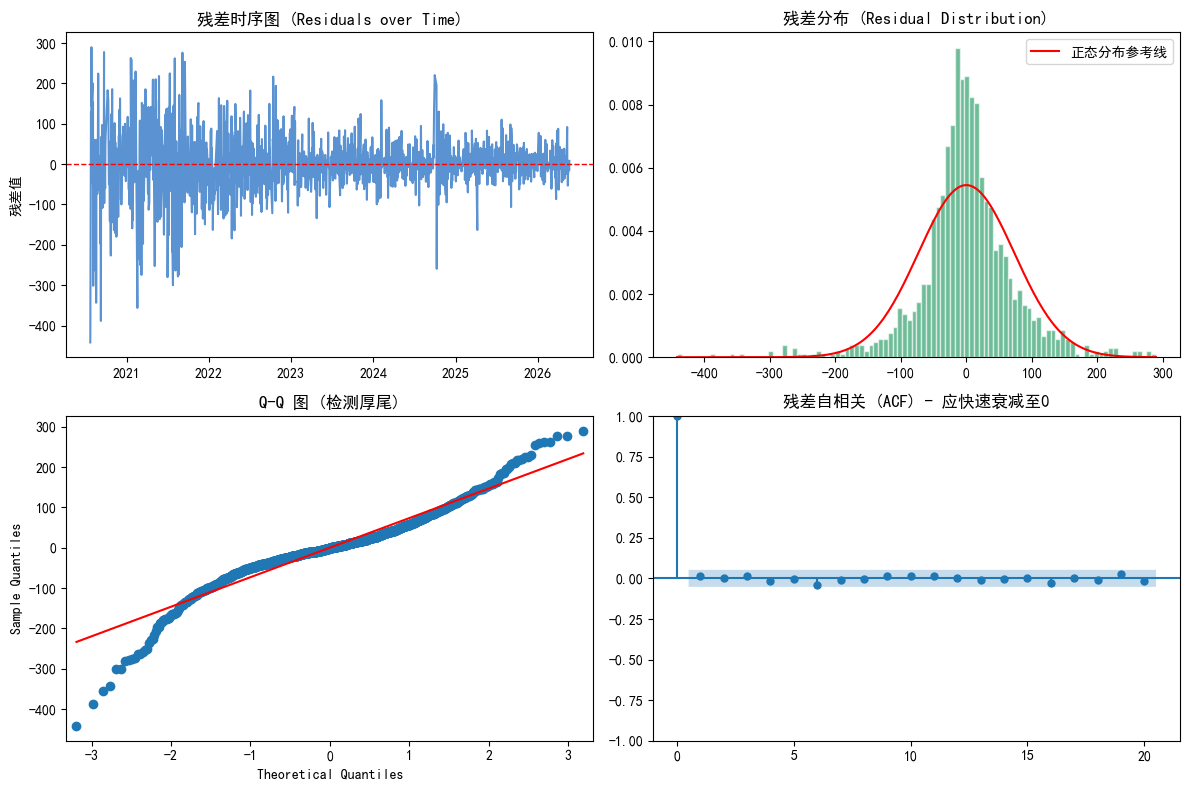

In [68]:
# 残差检验
train_residuals = train_fit.resid['close']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
resid_clean = train_residuals.dropna()

# 子图1: 残差时序图 (检查均值和方差的稳定性)
axes[0, 0].plot(resid_clean, color='#1565C0', alpha=0.7)
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('残差时序图 (Residuals over Time)')
axes[0, 0].set_ylabel('残差值')

# 子图2: 残差直方图 + 核密度曲线
axes[0, 1].hist(resid_clean, bins=100, density=True, alpha=0.6, color='#0D9253', edgecolor='white')
# 叠加正态分布曲线对比
mu, std = np.mean(resid_clean), np.std(resid_clean)
x = np.linspace(resid_clean.min(), resid_clean.max(), 200)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, std), 'r-', label='正态分布参考线')
axes[0, 1].set_title('残差分布 (Residual Distribution)')
axes[0, 1].legend()

# 子图3: Q-Q 图 (Quantile-Quantile) - 检查尾部特征
sm.qqplot(resid_clean, line='s', ax=axes[1, 0])
axes[1, 0].set_title('Q-Q 图 (检测厚尾)')

# 子图4: 残差自相关函数 (ACF) —— 决定性指标
plot_acf(resid_clean, ax=axes[1, 1], lags=20, alpha=0.05)
axes[1, 1].set_title('残差自相关 (ACF) - 应快速衰减至0')

plt.savefig(r'../data/var_resid.png')
plt.tight_layout()
plt.show()

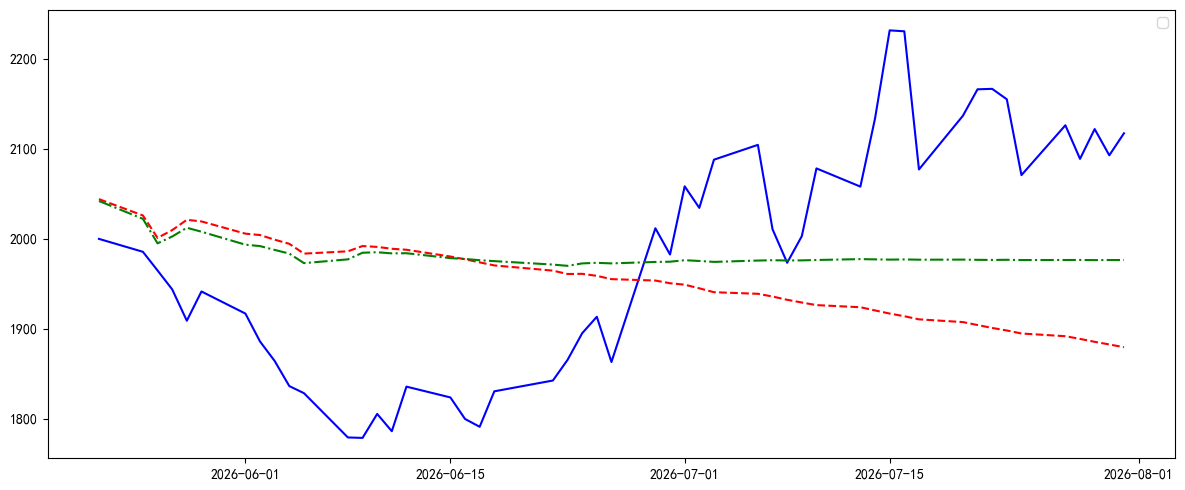

In [69]:
x = val_data_diff.iloc[-backtest_steps:].index
y2 = backtest_pred
y1 = actual_test
y3 = vecm_bt_pred
fig,ax = plt.subplots(figsize=(12,5))
ax.plot(x,y1,'b',x,y2,'r--',x,y3,'g-.')
ax.legend()
plt.tight_layout()
plt.show()

### 时序多变量VAR和单变量ARIMA拟合效果都不好，改用机器学习模型

In [70]:
# 构建训练数据
feature_cols = [c for c in data.columns if c not in ['close']]
dfs = data.copy()
dfs['target'] = dfs['close'].shift(-1)
dfs.dropna(inplace=True)
s = int(len(dfs)*0.85)
train = dfs.iloc[:s]
# test = dfs.iloc[s:]
# 使用孤立森林对交易量和收益率做异常检测
train_isolate = train[['volume','returns']].values
iso_clf = IsolationForest(contamination=0.05)  # 预期异常比例
iso_clf.fit(train_isolate)
# iso_clf.predict(test[['volume','returns']])
dfs['anomaly'] = iso_clf.predict(dfs[['volume','returns']].values)

train = dfs.iloc[:s]
test = dfs.iloc[s:]
x_train = train[feature_cols]
y_train = train['target']
x_test = test[feature_cols]
y_test = test['target']

In [71]:
# XGB 模型
results = {}
xgb_model = xgb.XGBRegressor(
    n_estimators=500, 
    max_depth=6, 
    learning_rate=0.05,
    subsample=0.8, 
    colsample_bytree=0.8, 
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42, 
    n_jobs=-1
                        )
xgb_model.fit(x_train[:-100], y_train[:-100], eval_set=[(x_train[-100:], y_train[-100:])], verbose=False)

pred_test_xgb = xgb_model.predict(x_test)
xgb_mae = mean_absolute_error(y_test, pred_test_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, pred_test_xgb))
xgb_mape = np.mean(np.abs((y_test - pred_test_xgb) / y_test)) * 100
results['xgb'] = {'mae':xgb_mae, 'rmse':xgb_rmse, 'mape':xgb_mape}

In [72]:
importance = pd.DataFrame({'feature': feature_cols,'importance': xgb_model.feature_importances_ }).sort_values('importance', ascending=False)
# 前10各重要特征
importance[:10]

,feature,importance
1,high,0.341030
50,close_lag2,0.335545
2,low,0.104762
24,ema26,0.051492
10,ma5,0.047903
14,ma20,0.040155
22,ema5,0.025114
16,ma60,0.020754
0,open,0.006373
52,close_lag3,0.006360


In [73]:
#随机森林模型
rf_model = RandomForestRegressor(
    n_estimators=300, 
    max_depth=12, 
    min_samples_split=10,
    min_samples_leaf=5, 
    random_state=42, 
    n_jobs=-1
                                )
rf_model.fit(x_train, y_train)

rf_pred_test = rf_model.predict(x_test)
rf_mae = mean_absolute_error(y_test, rf_pred_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_mape = np.mean(np.abs((y_test - rf_pred_test) / y_test)) * 100
results['rf'] = {'mae':rf_mae, 'rmse':rf_rmse, 'mape':rf_mape}

In [74]:
importance_rf = pd.DataFrame({'feature': feature_cols,'importance': rf_model.feature_importances_ }).sort_values('importance', ascending=False)
# 前10各重要特征
importance_rf[:10]

,feature,importance
1,high,0.599920
2,low,0.299599
0,open,0.030261
48,close_lag1,0.024323
10,ma5,0.018954
22,ema5,0.009570
50,close_lag2,0.002612
18,ma120,0.002195
14,ma20,0.002160
12,ma10,0.002155


In [75]:
# Ridge回归
scaler = StandardScaler()
r_train = scaler.fit_transform(train[feature_cols])
r_test = scaler.transform(test[feature_cols])
# y_train = train['target'].values
# y_test = test['target'].values

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(r_train, y_train)

pred_test_ridge = ridge_model.predict(r_test)
ridge_mae = mean_absolute_error(y_test, pred_test_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, pred_test_ridge))
ridge_mape = np.mean(np.abs((y_test - pred_test_ridge) / y_test)) * 100
results['ridge'] = {'mae':ridge_mae, 'rmse':ridge_rmse, 'mape':ridge_mape}
results

{'xgb': {'mae': 34.18953520463824,
  'rmse': 46.36014616740461,
  'mape': 1.5786798156168285},
 'rf': {'mae': 36.84371562151687,
  'rmse': 49.75935241961845,
  'mape': 1.6624141434280049},
 'ridge': {'mae': 29.378430263950193,
  'rmse': 39.441060489589226,
  'mape': 1.3598604988693508}}

In [76]:
# 定义LSMT模型
class LSTMModel(nn.Module):
    def __init__(self,input_size=1, hidden_size=64, num_layers=2,output_size=1):
        super(LSTMModel,self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first = True, dropout = 0.2)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self,x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out,_ = self.lstm(x,(h0,c0))
        out = self.fc(out[:,-1,:])
        return out

In [77]:
# 训练深度模型
def trainLsmtModel(data):
    device = torch.device('cpu')
    # 使用close价格
    close_price = data['target'].values.reshape(-1,1)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(close_price)
    # 构建序列
    seq_len = 30
    x,y = [],[]
    for i in range(seq_len,len(scaled)):
        x.append(scaled[i-seq_len:i,0])
        y.append(scaled[i,0])
    x = np.array(x)
    y = np.array(y)
    split_idx = 222 #int(len(data)*0.85)
    x_train = torch.FloatTensor(x[:-split_idx]).unsqueeze(-1).to(device)
    y_train = torch.FloatTensor(y[:-split_idx]).to(device)
    x_test = torch.FloatTensor(x[-split_idx:]).unsqueeze(-1).to(device)
    y_test = torch.FloatTensor(y[-split_idx:]).to(device)

    model = LSTMModel(input_size=1, hidden_size=64, num_layers=2).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(),lr=0.005)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,patience=10,factor=0.5)
    epochs = 150
    best_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(x_train)
        loss = criterion(outputs.squeeze(),y_train)
        loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            test_outputs = model(x_test)
            test_loss = criterion(test_outputs.squeeze(),y_test)

        scheduler.step(test_loss)
        if test_loss.item() < best_loss:
            best_loss = test_loss.item()
            best_state = model.state_dict().copy()
    model.load_state_dict(best_state)
    # 评估
    model.eval()
    with torch.no_grad():
        pred_test = model(x_test).squeeze().cpu().numpy()  
    pred_test_unscaled = scaler.inverse_transform(pred_test.reshape(-1,1)).flatten()
    actual_test = scaler.inverse_transform(y_test.cpu().numpy().reshape(-1,1)).flatten()
    mae = mean_absolute_error(actual_test,pred_test_unscaled)    
    rmse = np.sqrt(mean_squared_error(actual_test,pred_test_unscaled))
    mape = np.mean(np.abs((actual_test - pred_test_unscaled)/actual_test))*100
    print(f'LSTM: MAE={mae:.2f}; RMSE={rmse:.2f}; MAPE={mape:.2f}%')
    return pred_test_unscaled,{'mae':mae,'rmse':rmse,'mape':mape}
lsmt_data = dfs.drop(columns='close')
pred_lstm,metrics_dict = trainLsmtModel(lsmt_data)

LSTM: MAE=56.30; RMSE=73.05; MAPE=2.65%


In [78]:
results['lstm'] = metrics_dict
results

{'xgb': {'mae': 34.18953520463824,
  'rmse': 46.36014616740461,
  'mape': 1.5786798156168285},
 'rf': {'mae': 36.84371562151687,
  'rmse': 49.75935241961845,
  'mape': 1.6624141434280049},
 'ridge': {'mae': 29.378430263950193,
  'rmse': 39.441060489589226,
  'mape': 1.3598604988693508},
 'lstm': {'mae': 56.297523, 'rmse': 73.047714, 'mape': 2.6504365727305412}}

In [79]:
# 反MAPE加权
weights = {}
total_inv_mape = sum(1/m['mape'] for m in results.values())
for name,metrics in results.items():
    weights[name] = (1/metrics['mape'])/total_inv_mape
weights

{'xgb': 0.26982003154723466,
 'rf': 0.25622943556914135,
 'ridge': 0.31323759900877857,
 'lstm': 0.1607129338748454}

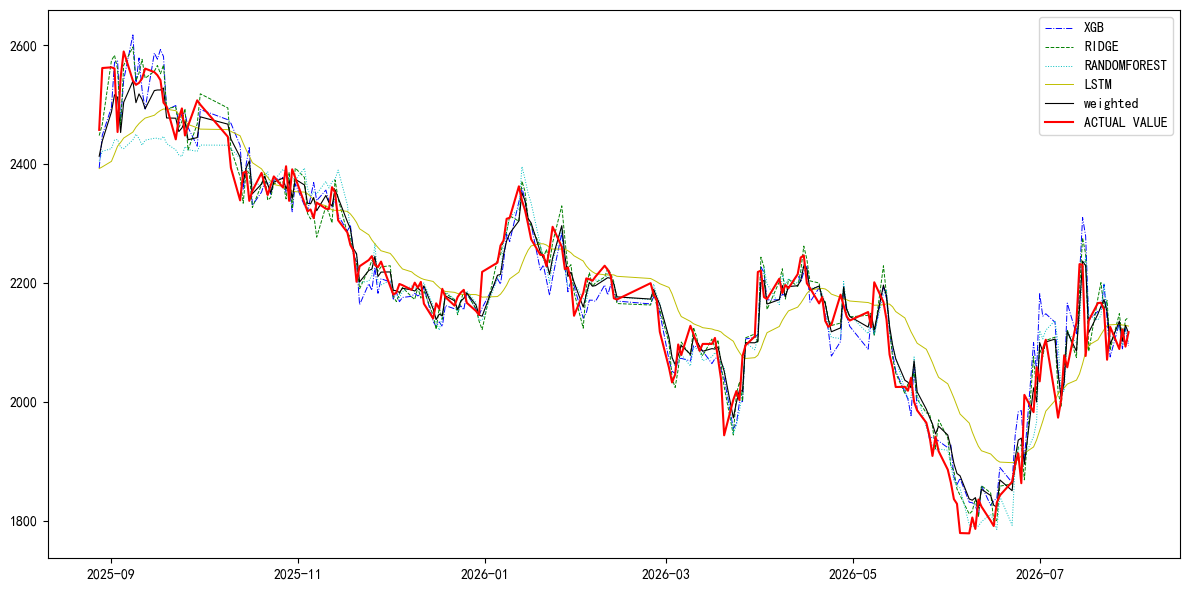

In [80]:
weight_pred = pred_test_xgb * weights['xgb'] + pred_test_ridge * weights['ridge'] + rf_pred_test * weights['rf'] + pred_lstm * weights['lstm']
fig,axs = plt.subplots(figsize=(12,6))
x = x_test.index
axs.plot(x,pred_test_xgb,'b-.',linewidth=0.7,label='XGB')
axs.plot(x,pred_test_ridge,'g--',linewidth=0.7,label='RIDGE')
axs.plot(x,rf_pred_test,'c:',linewidth=0.7,label='RANDOMFOREST')
axs.plot(x,pred_lstm,'y-',linewidth=0.7,label='LSTM')
axs.plot(x,weight_pred,'k',linewidth=0.8,label='weighted')
axs.plot(x,y_test,'r-',label='ACTUAL VALUE')
axs.legend()
plt.savefig(r'../image/predvalue.png')
plt.tight_layout()
plt.show()

In [81]:
# 画残差图检验残差
def residual_plot(actual,pred):
    train_residuals = actual - pred
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    resid_clean = train_residuals.dropna()
    
    # 子图1: 残差时序图 (检查均值和方差的稳定性)
    axes[0, 0].plot(resid_clean, color='#1565C0', alpha=0.7)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[0, 0].set_title('残差时序图 (Residuals over Time)')
    axes[0, 0].set_ylabel('残差值')
    
    # 子图2: 残差直方图 + 核密度曲线
    axes[0, 1].hist(resid_clean, bins=100, density=True, alpha=0.6, color='#0D9253', edgecolor='white')
    # 叠加正态分布曲线对比
    mu, std = np.mean(resid_clean), np.std(resid_clean)
    x = np.linspace(resid_clean.min(), resid_clean.max(), 200)
    axes[0, 1].plot(x, stats.norm.pdf(x, mu, std), 'r-', label='正态分布参考线')
    axes[0, 1].set_title('残差分布 (Residual Distribution)')
    axes[0, 1].legend()
    
    # 子图3: Q-Q 图 (Quantile-Quantile) - 检查尾部特征
    sm.qqplot(resid_clean, line='s', ax=axes[1, 0])
    axes[1, 0].set_title('Q-Q 图 (检测厚尾)')
    
    # 子图4: 残差自相关函数 (ACF) —— 决定性指标
    plot_acf(resid_clean, ax=axes[1, 1], lags=20, alpha=0.05)
    axes[1, 1].set_title('残差自相关 (ACF) - 应快速衰减至0')
    
    plt.savefig(r'../image/var_resid.png')
    plt.tight_layout()
    plt.show()

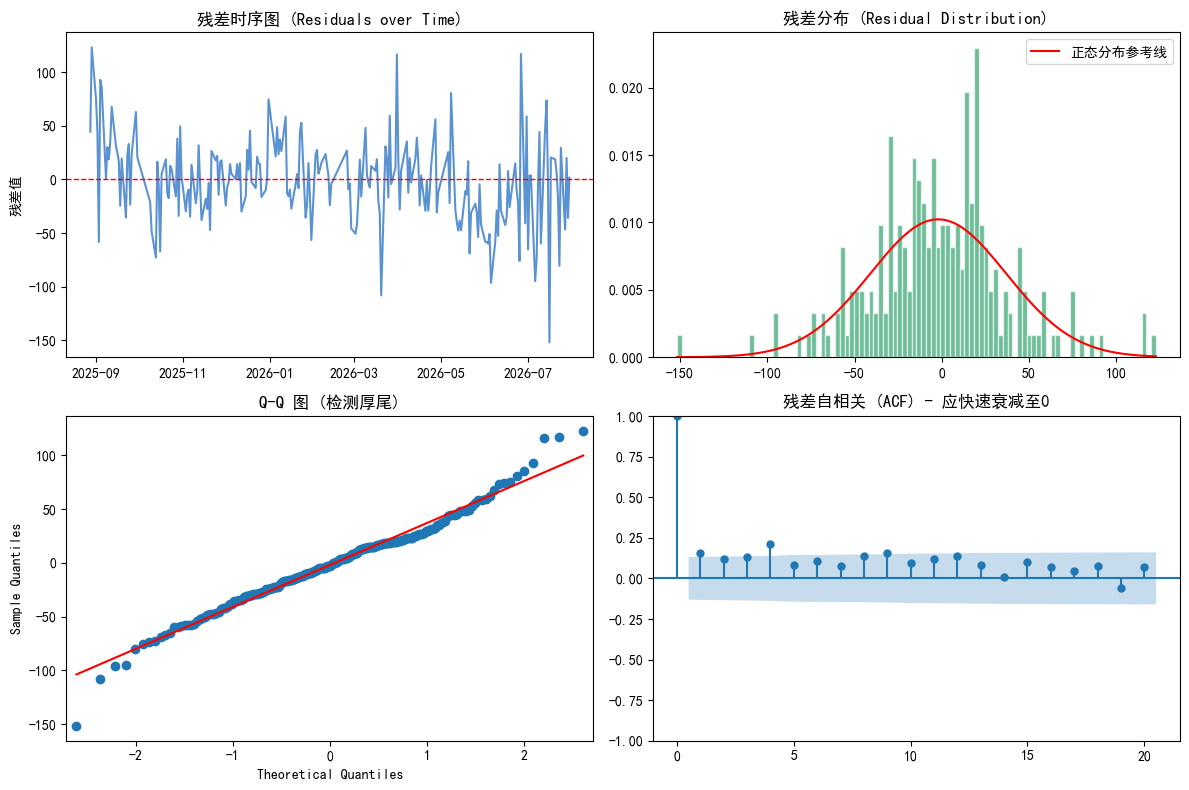

In [82]:
residual_plot(y_test,weight_pred)

In [88]:
print('|NAME  |MAE   |RMSE  |MAPE  |')
print('-'*4*7)
for key ,values in results.items():
    print(f'|{key:>6s}|{values['mae']:>6.2f}|{values['rmse']:>6.2f}|{values['mape']:>6.2f}%|')

|NAME  |MAE   |RMSE  |MAPE  |
----------------------------
|   xgb| 34.19| 46.36|  1.58%|
|    rf| 36.84| 49.76|  1.66%|
| ridge| 29.38| 39.44|  1.36%|
|  lstm| 56.30| 73.05|  2.65%|
